In [117]:
import numpy as np
def hex_to_dec(num):
    lookup = "ABCDEF"
    ans = 0
    for char in num:
        try:
            curr = int(char)
        except:
            curr =10+lookup.find(char)
        ans*=16
        ans+=curr
    return ans
def dec_to_bin(number: int, bits=-1):
    number=int(np.round(number, 0))
    neg=False
    out=""
    if (number<0):
        number*=-1
        number-=1
        neg=True
    while (number>0):
        res = number%2
        if (neg):
            res= 0 if (res==1) else 1
        out=f"{res}{out}"
        if (len(out)==(bits-1)):
            break
        number=int(number/2)
        
    if (neg):
        out=f"{1}{out}"
    else: out=f"{0}{out}"
    if (len(out)==0):
        out="0"
    while (len(out)<bits):
        out=f"{out[0]}{out}"
    return out
def dec_to_bin_unsigned(number: int, bits=-1):
    number=int(np.round(number, 0))
    out=""
    while (number>0):
        res = number%2
        out=f"{res}{out}"
        if (len(out)==(bits)):
            break
        number=int(number/2)
    if (len(out)==0):
        out="0"
    while (len(out)<bits):
        out=f"0{out}"
    return out
def bin_to_dec(number: str):
    output = 0
    neg = False
    if (number[0]=="1"):
        neg = True
    for i, char in enumerate(number[:0:-1]):
        if (neg):
            output+=(1-int(char))*(2**i)
        else:
            output+=int(char)*(2**i)
    if (neg):
        output*=-1
        output-=1
    return output
def hex_to_bin(num, width=0):
    ans = ""
    for char in num:
        ans+=dec_to_bin_unsigned(hex_to_dec(char),4)
    return ans[-width:]
def hex_to_int(num, width=0):
    ans = ""
    for char in num:
        ans+=dec_to_bin_unsigned(hex_to_dec(char),4)
    return bin_to_dec(ans[-width:])

4
131072.0


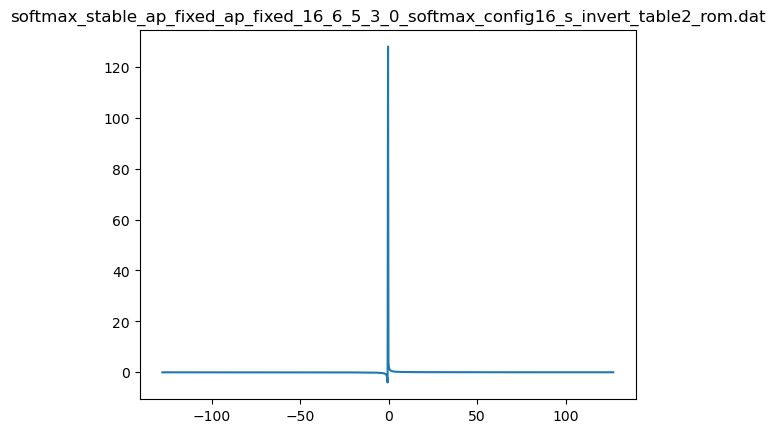

In [118]:
import numpy as np
import os
import scipy.optimize as opt
def fit_eq(x, a, b, c):
    y = np.exp(b*x-c)
    return y
table = np.zeros(1024)
table_raw = np.zeros(1024)
i=0
directory="model_5/hls_16_6_base/myproject_prj/solution1/syn/verilog"
files = os.listdir(directory)
tables = []
for file in files:
    if ".dat" in file:
        tables.append(file)
width=18
nfrac=10
bins = []
with open(os.path.join(directory, tables[0]), "r") as f:
    current = f.readline()
    while (len(current)>1):
        bins.append(f"{hex_to_bin(current[:-1],18)}\n")
        table[i] = hex_to_int(current[:-1],18)/2**nfrac
        i+=1
        current = f.readline()
import matplotlib.pyplot as plt
lookup_nfrac = 2
x_var = np.linspace(-512//(2**lookup_nfrac), 511//(2**lookup_nfrac), 1024)
with open("table_dump", "w") as f:
    f.writelines(bins)
for i, val in enumerate((table==1)):
    if (val):
        print(i)
print(np.max(table*2**nfrac)+1)
plt.plot(x_var, np.concatenate((table[int(1024/2):],table[0:int(1024/2)])))
plt.title(tables[0])
plt.show()